In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [2]:
# load data
df = pd.read_csv('/kaggle/input/competitions/spaceship-titanic/train.csv')
df_test = pd.read_csv('/kaggle/input/competitions/spaceship-titanic/test.csv')

## EDA

In [3]:
df.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [4]:
df.tail()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
8688,9276_01,Europa,False,A/98/P,55 Cancri e,41.0,True,0.0,6819.0,0.0,1643.0,74.0,Gravior Noxnuther,False
8689,9278_01,Earth,True,G/1499/S,PSO J318.5-22,18.0,False,0.0,0.0,0.0,0.0,0.0,Kurta Mondalley,False
8690,9279_01,Earth,False,G/1500/S,TRAPPIST-1e,26.0,False,0.0,0.0,1872.0,1.0,0.0,Fayey Connon,True
8691,9280_01,Europa,False,E/608/S,55 Cancri e,32.0,False,0.0,1049.0,0.0,353.0,3235.0,Celeon Hontichre,False
8692,9280_02,Europa,False,E/608/S,TRAPPIST-1e,44.0,False,126.0,4688.0,0.0,0.0,12.0,Propsh Hontichre,True


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


In [6]:
df.isna().sum()

PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64

In [7]:
df.nunique()

PassengerId     8693
HomePlanet         3
CryoSleep          2
Cabin           6560
Destination        3
Age               80
VIP                2
RoomService     1273
FoodCourt       1507
ShoppingMall    1115
Spa             1327
VRDeck          1306
Name            8473
Transported        2
dtype: int64

In [8]:
cryo_ratio = df["CryoSleep"].value_counts()
home_planet_count = df["HomePlanet"].value_counts()
dest_count = df["Destination"].value_counts()
vip_count = df["VIP"].value_counts()

print(cryo_ratio, home_planet_count, dest_count, vip_count)

CryoSleep
False    5439
True     3037
Name: count, dtype: int64 HomePlanet
Earth     4602
Europa    2131
Mars      1759
Name: count, dtype: int64 Destination
TRAPPIST-1e      5915
55 Cancri e      1800
PSO J318.5-22     796
Name: count, dtype: int64 VIP
False    8291
True      199
Name: count, dtype: int64


## Data Preprocessing / Feature Engineering

In [9]:
cat_col = ['CryoSleep', 'HomePlanet', 'Destination', 'VIP']
num_col = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

In [10]:
df['TotalExpenses'] = df[num_col].sum(axis=1)

<Axes: xlabel='Age', ylabel='Count'>

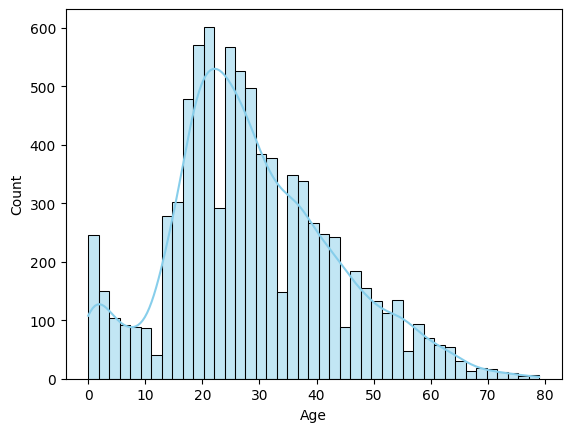

In [11]:
sns.histplot(data=df, x='Age', kde=True, color='skyblue')

In [12]:
df[['Group', 'NumberInGroup']] = df['PassengerId'].str.split('_', expand=True)
df[['Deck', 'CabinNumber', 'Side']] = df['Cabin'].str.split('/', expand=True)
df[['FirstName', 'LastName']] = df['Name'].str.split(' ', expand=True)

In [13]:
# anyone w/ 0 as their total expenses will be assumed to be in CryoSleep
df.loc[df['TotalExpenses'] == 0, 'CryoSleep'] = True

for col in num_col:
    df[col] = df[col].fillna(0)

for col in cat_col:
    df[col] = df[col].fillna(df[col].mode()[0])

df['Age'] = df['Age'].fillna(df['Age'].median())

/tmp/ipykernel_16/764057642.py:8: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(df[col].mode()[0])


In [14]:
drop_col = ['Name', 'Cabin']

df = df.drop(columns=drop_col)

In [15]:
cabin_details = ['Deck', 'CabinNumber', 'Side']
full_name = ['FirstName', 'LastName']

# replace CabinNumber missing values w/ -9999 (int)
for col in [cabin_details[1]]:
    df[col] = df[col].fillna(-9999)
    
# replace Deck and Side missing values w/ "N/A" (str)
for col in [cabin_details[0], cabin_details[2]]:
    df[col] = df[col].fillna("N/A")
    
for col in full_name:
    df[col] = df[col].fillna(-8888)

df.isna().info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   PassengerId    8693 non-null   bool 
 1   HomePlanet     8693 non-null   bool 
 2   CryoSleep      8693 non-null   bool 
 3   Destination    8693 non-null   bool 
 4   Age            8693 non-null   bool 
 5   VIP            8693 non-null   bool 
 6   RoomService    8693 non-null   bool 
 7   FoodCourt      8693 non-null   bool 
 8   ShoppingMall   8693 non-null   bool 
 9   Spa            8693 non-null   bool 
 10  VRDeck         8693 non-null   bool 
 11  Transported    8693 non-null   bool 
 12  TotalExpenses  8693 non-null   bool 
 13  Group          8693 non-null   bool 
 14  NumberInGroup  8693 non-null   bool 
 15  Deck           8693 non-null   bool 
 16  CabinNumber    8693 non-null   bool 
 17  Side           8693 non-null   bool 
 18  FirstName      8693 non-null   bool 
 19  LastNa

In [16]:
df['FamilyId'] = df['Group'].astype(str) + '_' + df['LastName'].astype(str)

# counts how many people w/ same family id
family_counts = df.groupby('FamilyId').size()

df['FamilySize'] = df['FamilyId'].map(family_counts)
df['IsFamily'] = (df['FamilySize'] > 1).astype(int)

# dropping columns that will cause overfitting later on
final_drop=['FamilyId', 'PassengerId', 'FirstName', 'LastName']

df.drop(columns=final_drop, inplace=True)

df.head()

,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,TotalExpenses,Group,NumberInGroup,Deck,CabinNumber,Side,FamilySize,IsFamily
0,Europa,True,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,False,0.0,0001,01,B,0,P,1,0
1,Earth,False,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,True,736.0,0002,01,F,0,S,1,0
2,Europa,False,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,False,10383.0,0003,01,A,0,S,2,1
3,Europa,False,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,False,5176.0,0003,02,A,0,S,2,1
4,Earth,False,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,True,1091.0,0004,01,F,1,S,1,0


In [17]:
le = LabelEncoder()
need_encoding = ['HomePlanet', 'Destination', 'Deck', 'Side'] # deck + side have multiple dtypes
int_convert = ['CryoSleep', 'VIP', 'Transported', 'Group', 'NumberInGroup', 'CabinNumber']

for col in int_convert:
    df[col] = df[col].astype(int)

for col in need_encoding: 
    df[f'{col}Encoded'] = le.fit_transform(df[col])

df = df.drop(columns=need_encoding)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CryoSleep           8693 non-null   int64  
 1   Age                 8693 non-null   float64
 2   VIP                 8693 non-null   int64  
 3   RoomService         8693 non-null   float64
 4   FoodCourt           8693 non-null   float64
 5   ShoppingMall        8693 non-null   float64
 6   Spa                 8693 non-null   float64
 7   VRDeck              8693 non-null   float64
 8   Transported         8693 non-null   int64  
 9   TotalExpenses       8693 non-null   float64
 10  Group               8693 non-null   int64  
 11  NumberInGroup       8693 non-null   int64  
 12  CabinNumber         8693 non-null   int64  
 13  FamilySize          8693 non-null   int64  
 14  IsFamily            8693 non-null   int64  
 15  HomePlanetEncoded   8693 non-null   int64  
 16  Destin

In [18]:
# features
X = df.drop(columns='Transported')
# label
y = df['Transported']

scaler = StandardScaler()
standard_df = scaler.fit_transform(X, y)
standard_df = pd.DataFrame(standard_df, columns=X.columns)

standard_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CryoSleep           8693 non-null   float64
 1   Age                 8693 non-null   float64
 2   VIP                 8693 non-null   float64
 3   RoomService         8693 non-null   float64
 4   FoodCourt           8693 non-null   float64
 5   ShoppingMall        8693 non-null   float64
 6   Spa                 8693 non-null   float64
 7   VRDeck              8693 non-null   float64
 8   TotalExpenses       8693 non-null   float64
 9   Group               8693 non-null   float64
 10  NumberInGroup       8693 non-null   float64
 11  CabinNumber         8693 non-null   float64
 12  FamilySize          8693 non-null   float64
 13  IsFamily            8693 non-null   float64
 14  HomePlanetEncoded   8693 non-null   float64
 15  DestinationEncoded  8693 non-null   float64
 16  DeckEn

## Model Building

In [19]:

from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

# split data 
X_train, X_test, y_train, y_test = train_test_split(standard_df, y, test_size=.2)

# create model instance
bst = XGBClassifier(n_estimators=2, max_depth=2, learning_rate=1, objective='binary:logistic')

# fit model
bst.fit(X_train, y_train)

# make predictions
preds = bst.predict(X_test)

In [20]:
# KFold
kf = KFold(n_splits=2, shuffle=True, random_state=42)

scores = cross_val_score(bst, X_test, y_test, cv=kf, scoring='accuracy')

print("Accuracy scores for each fold:", scores)
print("Mean Accuracy:", np.mean(scores))

Accuracy scores for each fold: [0.75862069 0.77100115]
Mean Accuracy: 0.7648109202015793
